# 🏦 Globe Bank International — Customer Retention Analysis

---

| Detail | Info |
|---|---|
| **Project** | Globe Bank International — Customer Retention Analysis |
| **Stage** | Stage 2 — Data Cleaning & Transformation |
| **Notebook** | 02_cleaning_transformation.ipynb |
| **Input** | `data/raw/BankChurners.csv` |
| **Output** | `data/processed/bank_churners_clean.csv` |

---

> **Goal:** Clean and transform the raw dataset into an analysis-ready file.
> This includes encoding the target variable, handling categorical ordinal
> ordering, feature engineering, and saving the processed data.

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import warnings

warnings.filterwarnings("ignore")
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## 🎨 Global Style Settings

In [2]:
COLOURS = {
    "retained":  "#2E86AB",
    "churned":   "#E84855",
    "neutral":   "#A8DADC",
    "highlight": "#F4A261",
}

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":      150,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

pio.renderers.default = "notebook"
print("✅ Global style settings applied.")

✅ Global style settings applied.


## 📂 Load Raw Data

In [3]:
df = pd.read_csv("../data/raw/BankChurners.csv")

# Drop Naive Bayes columns and CLIENTNUM
nb_cols = [
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]
df.drop(columns=nb_cols + ["CLIENTNUM"], inplace=True)

print(f"✅ Raw data loaded. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Raw data loaded. Shape: 10,127 rows × 20 columns


## 🎯 Encode Target Variable

In [4]:
# Encode Attrition_Flag: 0 = Retained, 1 = Churned
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
})

# Readable label for charts — not used as a model feature
df["Churn_Label"] = df["Attrition_Flag"].map({0: "Retained", 1: "Churned"})

print("✅ Target variable encoded.")
print(df["Attrition_Flag"].value_counts().rename({0: "Retained (0)", 1: "Churned (1)"}))


✅ Target variable encoded.
Attrition_Flag
Retained (0)    8500
Churned (1)     1627
Name: count, dtype: int64


## 🧹 Handle Missing Values

In [6]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("✅ No missing values found — no imputation required.")
else:
    print(f"⚠️  Missing values detected:\n{missing_cols}")

✅ No missing values found — no imputation required.


## 🔢 Ordinal Encoding — Categorical Columns

Some categorical columns have a natural order (e.g. education level,
income brackets). We encode these as ordered integers so they carry
meaningful information in analysis and modelling.

In [7]:

# Education_Level — ordered low to high (Unknown treated as separate)
education_order = [
    "Uneducated", "High School", "College",
    "Graduate", "Post-Graduate", "Doctorate", "Unknown"
]
df["Education_Level"] = pd.Categorical(
    df["Education_Level"], categories=education_order, ordered=True
)
df["Education_Encoded"] = df["Education_Level"].cat.codes

# Income_Category — ordered low to high (Unknown treated as separate)
income_order = [
    "Less than $40K", "$40K - $60K", "$60K - $80K",
    "$80K - $120K", "$120K +", "Unknown"
]
df["Income_Category"] = pd.Categorical(
    df["Income_Category"], categories=income_order, ordered=True
)
df["Income_Encoded"] = df["Income_Category"].cat.codes

# Card_Category — ordered by tier
card_order = ["Blue", "Silver", "Gold", "Platinum"]
df["Card_Category"] = pd.Categorical(
    df["Card_Category"], categories=card_order, ordered=True
)
df["Card_Encoded"] = df["Card_Category"].cat.codes

print("✅ Ordinal encoding applied.")
print(f"\nEducation mapping:\n{dict(enumerate(education_order))}")
print(f"\nIncome mapping:\n{dict(enumerate(income_order))}")
print(f"\nCard mapping:\n{dict(enumerate(card_order))}")

✅ Ordinal encoding applied.

Education mapping:
{0: 'Uneducated', 1: 'High School', 2: 'College', 3: 'Graduate', 4: 'Post-Graduate', 5: 'Doctorate', 6: 'Unknown'}

Income mapping:
{0: 'Less than $40K', 1: '$40K - $60K', 2: '$60K - $80K', 3: '$80K - $120K', 4: '$120K +', 5: 'Unknown'}

Card mapping:
{0: 'Blue', 1: 'Silver', 2: 'Gold', 3: 'Platinum'}


## 🔤 Nominal Encoding — Gender & Marital Status

These columns have no natural order, so we use simple binary or
dummy encoding.

In [8]:
# Gender — binary encode: M = 1, F = 0
df["Gender_Encoded"] = df["Gender"].map({"M": 1, "F": 0})

# Marital_Status — one-hot encode (drop first to avoid multicollinearity)
marital_dummies = pd.get_dummies(df["Marital_Status"], prefix="Marital", drop_first=True)
df = pd.concat([df, marital_dummies], axis=1)

print("✅ Nominal encoding applied.")
print(f"\nGender encoding: M=1, F=0")
print(f"\nMarital Status dummies created: {list(marital_dummies.columns)}")

✅ Nominal encoding applied.

Gender encoding: M=1, F=0

Marital Status dummies created: ['Marital_Married', 'Marital_Single', 'Marital_Unknown']


## ⚙️ Feature Engineering

Creating new features that may better capture customer behaviour
and improve analytical insight.

In [9]:
# Transaction frequency ratio — how often they transact relative to relationship length
df["Trans_Freq_Ratio"] = df["Total_Trans_Ct"] / (df["Months_on_book"] + 1)

# Inactivity rate — proportion of last 12 months spent inactive
df["Inactivity_Rate"] = df["Months_Inactive_12_mon"] / 12

# Credit utilisation band — categorise utilisation ratio into bins
df["Utilisation_Band"] = pd.cut(
    df["Avg_Utilization_Ratio"],
    bins=[-0.01, 0.10, 0.30, 0.60, 1.01],
    labels=["Very Low", "Low", "Medium", "High"]
)

# Contact intensity — contacts per month on book
df["Contact_Intensity"] = df["Contacts_Count_12_mon"] / (df["Months_on_book"] + 1)

print("✅ New features engineered:")
print("   - Trans_Freq_Ratio")
print("   - Inactivity_Rate")
print("   - Utilisation_Band")
print("   - Contact_Intensity")

✅ New features engineered:
   - Trans_Freq_Ratio
   - Inactivity_Rate
   - Utilisation_Band
   - Contact_Intensity


## ✅ Post-Cleaning Validation

In [10]:
print("=== Post-Cleaning Validation ===\n")
print(f"Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values    : {df.isnull().sum().sum()}")
print(f"Duplicate rows    : {df.duplicated().sum()}")
print(f"\nColumn list ({df.shape[1]} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

=== Post-Cleaning Validation ===

Shape             : 10,127 rows × 32 columns
Missing values    : 0
Duplicate rows    : 0

Column list (32 total):
   1. Attrition_Flag
   2. Customer_Age
   3. Gender
   4. Dependent_count
   5. Education_Level
   6. Marital_Status
   7. Income_Category
   8. Card_Category
   9. Months_on_book
  10. Total_Relationship_Count
  11. Months_Inactive_12_mon
  12. Contacts_Count_12_mon
  13. Credit_Limit
  14. Total_Revolving_Bal
  15. Avg_Open_To_Buy
  16. Total_Amt_Chng_Q4_Q1
  17. Total_Trans_Amt
  18. Total_Trans_Ct
  19. Total_Ct_Chng_Q4_Q1
  20. Avg_Utilization_Ratio
  21. Churn_Label
  22. Education_Encoded
  23. Income_Encoded
  24. Card_Encoded
  25. Gender_Encoded
  26. Marital_Married
  27. Marital_Single
  28. Marital_Unknown
  29. Trans_Freq_Ratio
  30. Inactivity_Rate
  31. Utilisation_Band
  32. Contact_Intensity


## 📊 Cleaned Data — Distributions Check

A quick visual check to confirm the cleaned numeric features
look sensible before saving.

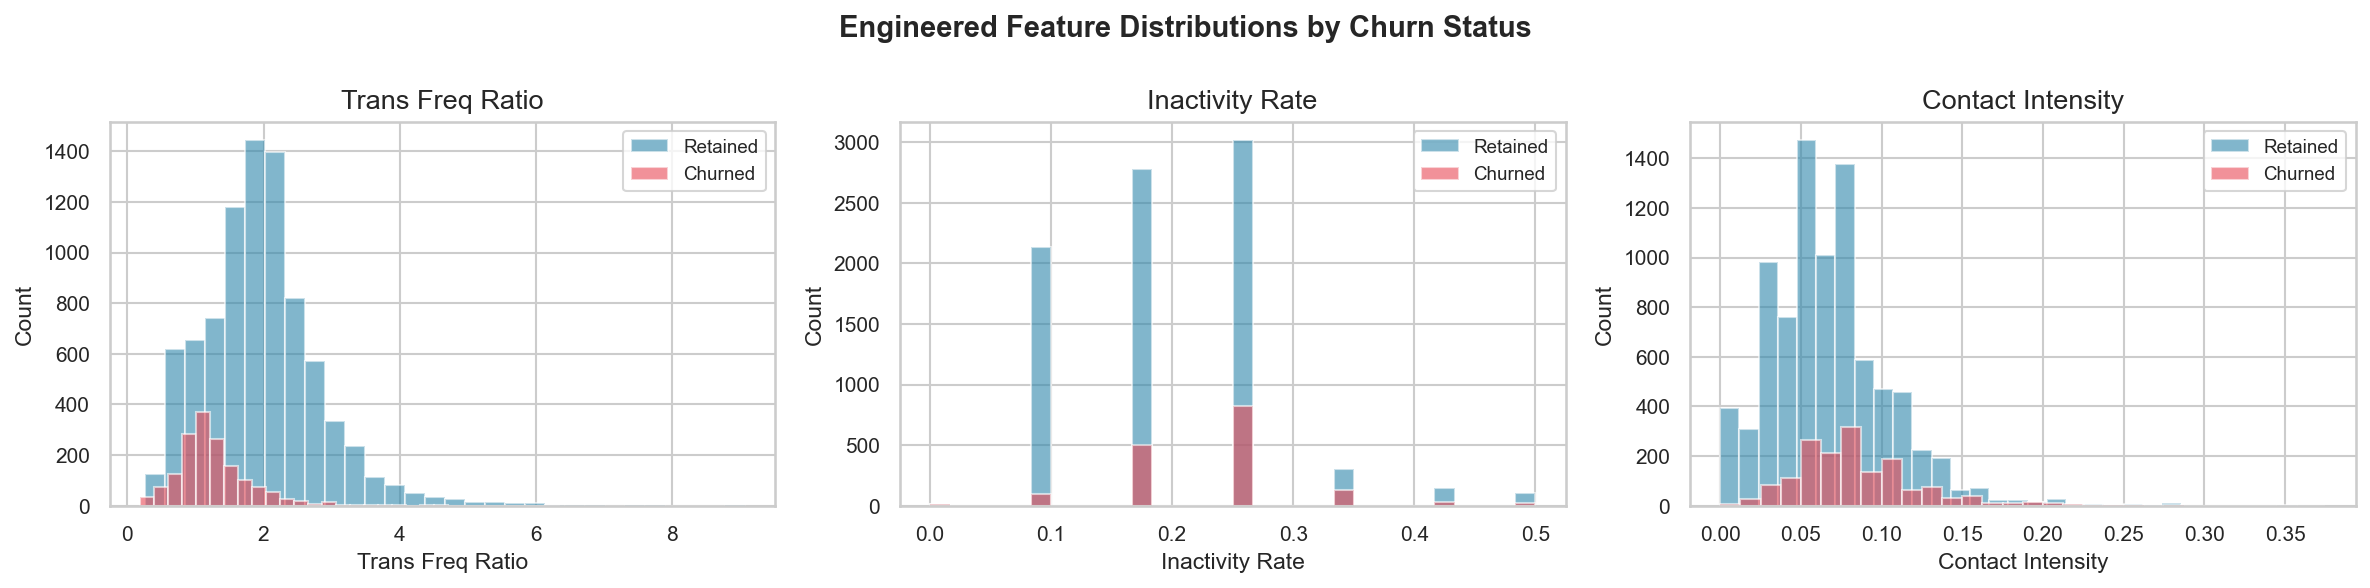

✅ Chart saved to outputs/figures/02_engineered_features.png


In [12]:
new_features = ["Trans_Freq_Ratio", "Inactivity_Rate", "Contact_Intensity"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Engineered Feature Distributions by Churn Status",
             fontsize=14, fontweight="bold")

for i, col in enumerate(new_features):
    for label, colour in zip(["Retained", "Churned"],
                              [COLOURS["retained"], COLOURS["churned"]]):
        subset = df[df["Churn_Label"] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=colour,
                     label=label, edgecolor="white")
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_xlabel(col.replace("_", " "))
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/02_engineered_features.png", bbox_inches="tight")
plt.show()
print("✅ Chart saved to outputs/figures/02_engineered_features.png")

## 💾 Save Processed Data

In [14]:
output_path = "../data/processed/bank_churners_clean.csv"
df.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


✅ Cleaned dataset saved to: ../data/processed/bank_churners_clean.csv
   Shape: 10,127 rows × 32 columns


## 📝 Cleaning & Transformation Summary

In [15]:
summary = f"""
╔══════════════════════════════════════════════════════════════╗
║       STAGE 2 — CLEANING & TRANSFORMATION SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  Input rows      : 10,127                                    ║
║  Output rows     : {df.shape[0]:,} (no rows removed)               ║
║  Output columns  : {df.shape[1]} (original + encoded + engineered) ║
║  Missing values  : None                                      ║
║  Duplicates      : None                                      ║
╠══════════════════════════════════════════════════════════════╣
║  ENCODING APPLIED                                            ║
║  - Attrition_Flag  : Existing/Attrited → 0/1                 ║
║  - Education_Level : Ordinal encoded (0–6)                   ║
║  - Income_Category : Ordinal encoded (0–5)                   ║
║  - Card_Category   : Ordinal encoded (0–3)                   ║
║  - Gender          : Binary encoded  (M=1, F=0)              ║
║  - Marital_Status  : One-hot encoded (dummies)               ║
╠══════════════════════════════════════════════════════════════╣
║  FEATURES ENGINEERED                                         ║
║  - Trans_Freq_Ratio   : Transaction count / months on book   ║
║  - Inactivity_Rate    : Inactive months / 12                 ║
║  - Utilisation_Band   : Utilisation ratio binned             ║
║  - Contact_Intensity  : Contacts / months on book            ║
╠══════════════════════════════════════════════════════════════╣
║  OUTPUT FILE                                                 ║
║  data/processed/bank_churners_clean.csv                      ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEP: Stage 3 — Analysis & Insights                    ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║       STAGE 2 — CLEANING & TRANSFORMATION SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  Input rows      : 10,127                                    ║
║  Output rows     : 10,127 (no rows removed)               ║
║  Output columns  : 32 (original + encoded + engineered) ║
║  Missing values  : None                                      ║
║  Duplicates      : None                                      ║
╠══════════════════════════════════════════════════════════════╣
║  ENCODING APPLIED                                            ║
║  - Attrition_Flag  : Existing/Attrited → 0/1                 ║
║  - Education_Level : Ordinal encoded (0–6)                   ║
║  - Income_Category : Ordinal encoded (0–5)                   ║
║  - Card_Category   : Ordinal encoded (0–3)                   ║
║  - Gender          : Binary encoded  (M=1, F=0)              ║
║  - Marital_Status  : One-hot en